# MES / MNQ pairs mean reversion (Tradovate exchange)

Same event-driven engine, data source, and cost model as
`tradovate_ma_crossover/MES/step_2_run_full_backtest.ipynb` and
`mean-reversion/vwap_deviation_bands_mes.ipynb`: real OHLC resampled locally from
Databento's full-history 1-minute continuous-contract Parquet files
(`data_aggregator.databento_aggregator`, GLBX.MDP3), whole-contract position
sizing, tick-based slippage + per-contract fees, and a Tradeify-style EOD-trailing
drawdown risk middleware. The strategy is different again: this trades a **spread
between two symbols** (`backtester.strategies.PairsMeanReversionStrategy`, new
this pass) instead of a single-symbol signal.

**Important caveat, from `cointegration/mes_mnq_m2k_cointegration.ipynb`, up front
not buried**: of the three pairs tested there, **MES/MNQ had the weakest
cointegration evidence** -- full-history Engle-Granger p=0.28-0.31, last-1-month
p=0.63-0.72, nowhere close to significant in either window. (`M2K/MNQ` and
`M2K/MES` showed actual, if marginal, evidence; MES/MNQ did not.) This pair was
chosen anyway, deliberately, not because the statistics support it -- treat this
notebook as an empirical test of "what happens if we trade the spread anyway,"
not a validated strategy. High return correlation (MES/MNQ was the *highest* of
the three pairs at 0.91-0.92) is a different claim from cointegration and doesn't
by itself justify betting on mean reversion in the price-level spread.

**Design**:
- **Signal**: a *rolling* (not fixed full-history) OLS hedge ratio and z-score of
  the log-price spread -- a fixed hedge ratio estimated once over years of data
  would bake in exactly the kind of stale, regime-dependent relationship the
  cointegration notebook's per-year check found. Entry/exit/stop are all expressed
  in z-score units, not a price percent (a symmetric price-percent stop doesn't
  mean anything across two different-priced, different-point-value legs).
- **Sizing**: `percent=1` (full notional) on *each* leg -- i.e. dollar-neutral
  equal notional per leg (long one side, short the other), the standard classic
  pairs-trade convention, not a hedge-ratio-scaled notional split. The rolling
  regression's beta is used for the *signal* (building a spread that should
  mean-revert); position sizing is kept simple on top of that.
- **Cost awareness**: a pairs trade pays commission+slippage on **four** fills per
  round trip (open leg A, open leg B, close leg A, close leg B) instead of two --
  fee drag has already proven decisive in this repo's other mean-reversion
  notebook (VWAP deviation bands), so total fees paid are tracked directly from
  the exchange event log for every grid combination below, not just inferred
  after the fact.


In [7]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import PairsMeanReversionStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit


In [8]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- plain
    # `jupyter nbconvert` uses the notebook's own directory, VS Code's Jupyter
    # extension uses the workspace root, etc. Walk upward until the target actually
    # exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL_A = "MES"
DISPLAY_SYMBOL_B = "MNQ"
SYMBOL_A = "MES/USD"
SYMBOL_B = "MNQ/USD"

INTERVAL = 15
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
mnq_path = _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd))

ohlc_a = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
ohlc_b = load_1m_parquet_resampled(mnq_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)

# Inner-join on common bar timestamps -- same care as the cointegration notebook,
# since the two Parquets were downloaded at slightly different times today.
common_index = ohlc_a.index.intersection(ohlc_b.index)
ohlc_a = ohlc_a.loc[common_index]
ohlc_b = ohlc_b.loc[common_index]
print(f"Aligned bars: {len(common_index)}  span: {common_index[0]} -> {common_index[-1]}")


Aligned bars: 168225  span: 2019-05-05 22:14:59.999000 -> 2026-07-12 23:14:59.999000


## Rolling hedge ratio and spread z-score

`ROLLING_WINDOW_BARS` controls both the hedge-ratio estimation window and the
z-score's own mean/std normalization window -- kept as one parameter rather than
two for simplicity; splitting them (e.g. a longer window for the hedge ratio, a
shorter one for the z-score) is a possible refinement, not attempted here.


z-score usable bars: 158227 / 168225 (first 5000 bars are NaN warmup)


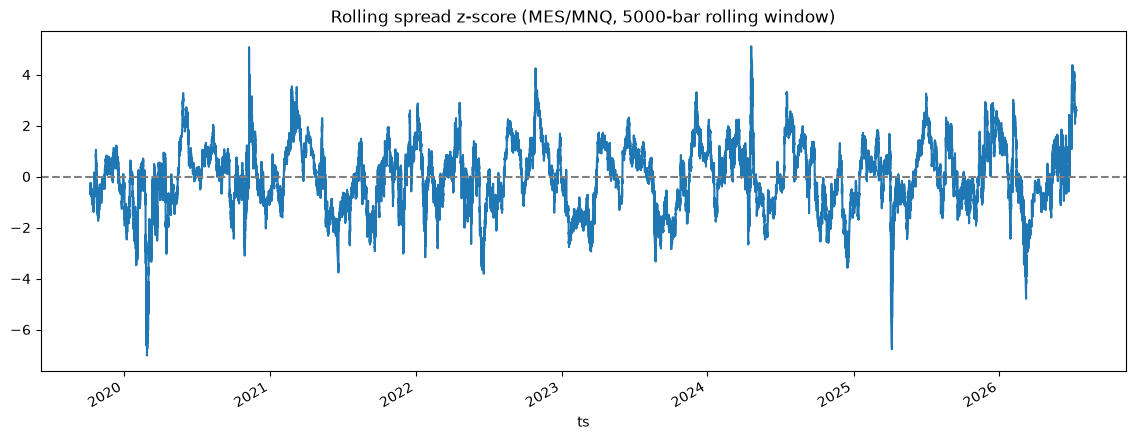

In [9]:
ROLLING_WINDOW_BARS = 5000  # ~a week of 5-minute bars (2000*5min ~= 6.9 days) --
# long enough to smooth noise, short enough to adapt to the regime instability the
# cointegration notebook found (a fixed full-history hedge ratio would bake in
# exactly the kind of stale relationship that analysis flagged as the problem).

log_a = np.log(ohlc_a["close"])
log_b = np.log(ohlc_b["close"])

roll_cov = log_a.rolling(ROLLING_WINDOW_BARS).cov(log_b)
roll_var_b = log_b.rolling(ROLLING_WINDOW_BARS).var()
hedge_ratio = roll_cov / roll_var_b
intercept = (
    log_a.rolling(ROLLING_WINDOW_BARS).mean() - hedge_ratio * log_b.rolling(ROLLING_WINDOW_BARS).mean()
)

spread = log_a - hedge_ratio * log_b - intercept
spread_mean = spread.rolling(ROLLING_WINDOW_BARS).mean()
spread_std = spread.rolling(ROLLING_WINDOW_BARS).std()
zscore = (spread - spread_mean) / spread_std

ZSCORE_KEY = "mes_mnq_spread_zscore"
print(f"z-score usable bars: {zscore.notna().sum()} / {len(zscore)} "
      f"(first {ROLLING_WINDOW_BARS} bars are NaN warmup)")

plt.figure(figsize=(14, 5))
zscore.plot()
plt.axhline(0, color="gray", linestyle="--")
plt.title(f"Rolling spread z-score ({DISPLAY_SYMBOL_A}/{DISPLAY_SYMBOL_B}, {ROLLING_WINDOW_BARS}-bar rolling window)")
plt.show()


In [10]:
market = Market()
market.add_market(symbol=SYMBOL_A, df=ohlc_a)
market.add_market(symbol=SYMBOL_B, df=ohlc_b)
market.add_indicator(
    symbol=SYMBOL_A, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
    indicator_name=ZSCORE_KEY, df=zscore,
)
market.compile()
print(f"Compiled {len(market.data)} candles across {list(market.markets.keys())}")


Compiled 168225 candles across ['MES/USD', 'MNQ/USD']


## Grid search: entry_z x exit_z

`stop_z` is fixed (not grid-searched) at a wide backstop -- this pair's weak
cointegration evidence means the spread genuinely might not revert, so this needs
to actually protect against a runaway divergence rather than being tuned for
performance. Total fees paid are pulled directly from the exchange event log
(`OrderFilled.fees_volume`, summed) for every combination, alongside the usual
return/Sharpe/drawdown numbers -- given a pairs trade's four-fills-per-round-trip
cost structure, this is checked every time, not just when something looks off.


In [ ]:
ENTRY_Z_CANDIDATES = [7.0]  # 1.5-4.0 in 0.5 increments, same as the other notebooks
EXIT_Z_CANDIDATES = [0.0]  # 0.0-2.0 in 0.5 increments, same as the other notebooks
STOP_Z = 2.0

DEPOSIT_USD = 50_000  # Tradeify Growth $50k account, same convention as the other notebooks


def run_pairs_backtest(entry_z: float, exit_z: float):
    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=PairsMeanReversionStrategy(
                key=f"PAIRS_MR_{entry_z}_{exit_z}_MES_MNQ",
                market=market,
                symbol=SYMBOL_A,
                symbol_b=SYMBOL_B,
                zscore_indicator_key=ZSCORE_KEY,
                entry_z=entry_z,
                exit_z=exit_z,
                stop_z=STOP_Z,
                direction=StrategyDirection.both,
            ),
        ),
    ], output_scale=1)

    # Same Tradovate cost model as the other notebooks: real tick_size/fee_per_contract
    # set directly on TRADOVATE_FUTURES in exchange_config.py, for both MES and MNQ.
    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market,
        slippage=0.0,
        maker_fee=0.0,
        taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL_A, SYMBOL_B], periods_per_year=252,
    )

    market.reset()
    # Loosened to 50%/50% instead of Tradeify's real 4%/2.5%: same reasoning as every
    # other notebook in this pipeline -- tests one strategy sleeve in isolation, ahead
    # of eventual multi-strategy combination where the real account-level limits apply.
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


import time

grid_rows = []
grid_backtests = {}
for entry_z in ENTRY_Z_CANDIDATES:
    for exit_z in EXIT_Z_CANDIDATES:
        _t0 = time.time()
        bt, drawdown_mw = run_pairs_backtest(entry_z, exit_z)
        print(f"entry_z={entry_z} exit_z={exit_z} done in {time.time() - _t0:.1f}s", flush=True)
        summary = bt.reporter.summary["algo"]
        # NOTE: bt.exchange.get_logs() returns rebalancer action logs, not the fill
        # event stream -- event_log.get_events() is the correct accessor (same one the
        # VWAP mean-reversion notebook uses). Fixed after an earlier run showed
        # total_fees_usd=0 despite a huge gross/net gap -- confirmed as a bug in this
        # diagnostic column only; net_return_percent/sharpe_ratio/etc above come from
        # the real engine and were never affected.
        total_fees = sum(
            log.fees_volume for log in bt.exchange.event_log.get_events() if isinstance(log, OrderFilled)
        )
        grid_backtests[(entry_z, exit_z)] = (bt, drawdown_mw)
        grid_rows.append({
            "entry_z": entry_z, "exit_z": exit_z,
            "net_return_percent": summary["net_return_percent"],
            "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"],
            "closed_trades": summary["closed_trades"],
            "win_rate_percent": summary["win_rate_percent"],
            "total_fees_usd": total_fees,
            "account_failed": drawdown_mw.account_failed,
        })

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
grid_results


entry_z=5.0 exit_z=0.0 done in 3.6s


,entry_z,exit_z,net_return_percent,sharpe_ratio,max_drawdown_percent,closed_trades,win_rate_percent,total_fees_usd,account_failed
0,5.0,0.0,-6.19996,-0.534116,-6.2,314.0,49.363057,1299.48,False


## Detailed report for the best (entry_z, exit_z)

Full HTML summary table (with year-by-year split), equity/drawdown/exposure
charts, for whichever combo above ranked best by Sharpe -- same report format as
the other notebooks in this pipeline.


Best combo: entry_z=5.0, exit_z=0.0
Candles Processed: 168224
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,MNQ/USD,description
sharpe_ratio,-0.5341,0.0000,-1.4859,0.0000,0.0000,0.0000,0.8298,-0.3921,0.0000,0.6392,0.7294,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-0.5591,0.0000,-1.4864,0.0000,0.0000,0.0000,0.0000,-0.4555,0.0000,0.9137,1.0539,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,1.1381,0.0000,2.4992,0.0000,0.0000,0.0000,0.0411,1.7398,0.0000,16.6830,20.8050,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-0.8860,0.0000,-5.2945,0.0000,0.0000,0.0000,0.0496,-1.0079,0.0000,14.3689,20.7347,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.1429,0.0000,-0.9582,0.0000,0.0000,0.0000,0.0000,-0.5653,0.0000,0.4057,0.5852,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-1.0000,0.0000,-0.9582,0.0000,0.0000,0.0000,0.0000,-0.5637,0.0000,4.5918,8.1200,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-6.2000,-0.0000,-5.5256,-0.0000,-0.0000,-0.0000,-0.0000,-1.7830,-0.0000,-35.4168,-35.4337,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2330,0,311,0,0,0,0,269,0,719,751,How long it took to recover the loss. Shorter is better.
ulcer_index,5.1830,0.0000,5.0376,0.0000,0.0000,0.0000,0.0000,1.5308,0.0000,8.4634,11.9964,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.4858,-2.0298,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


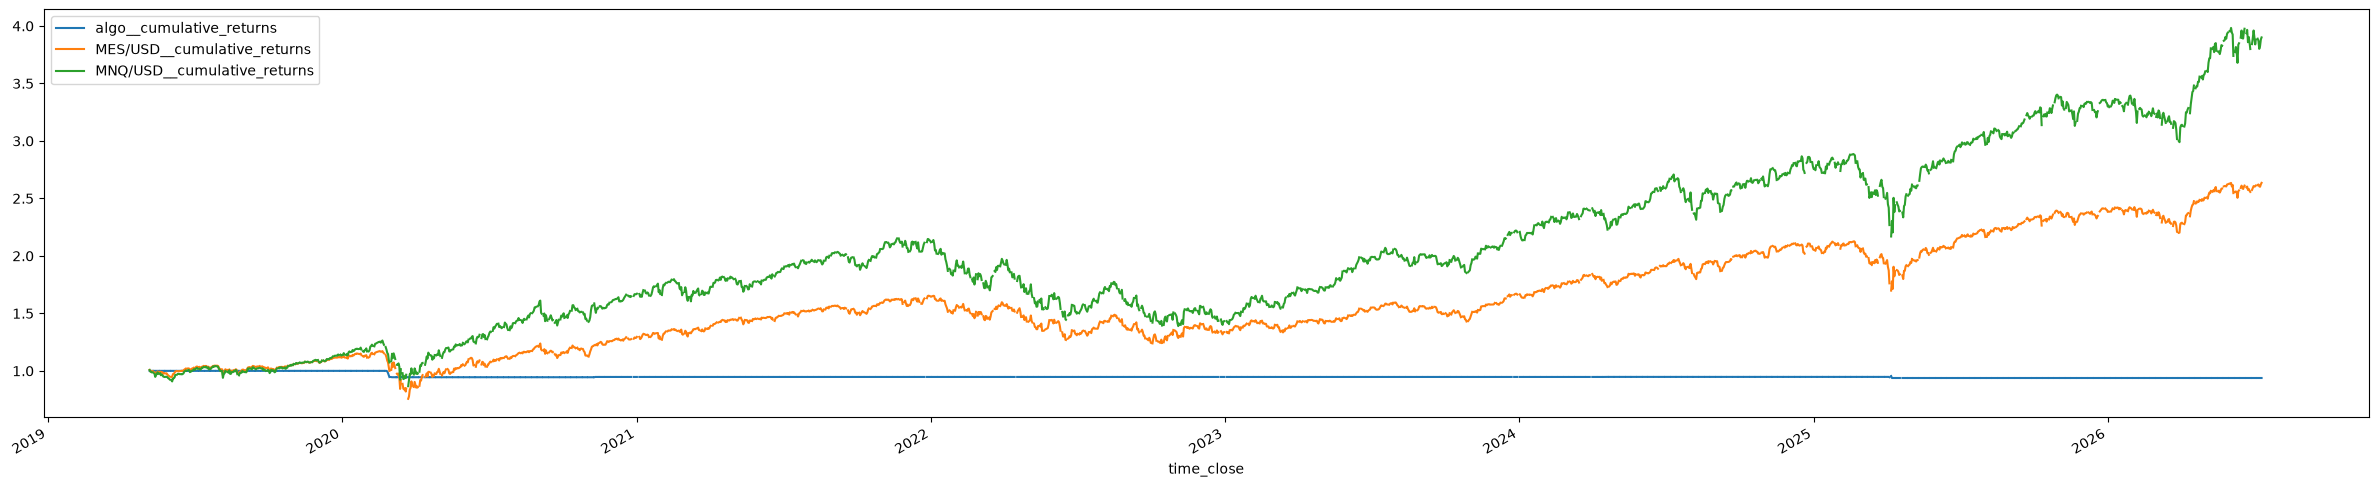

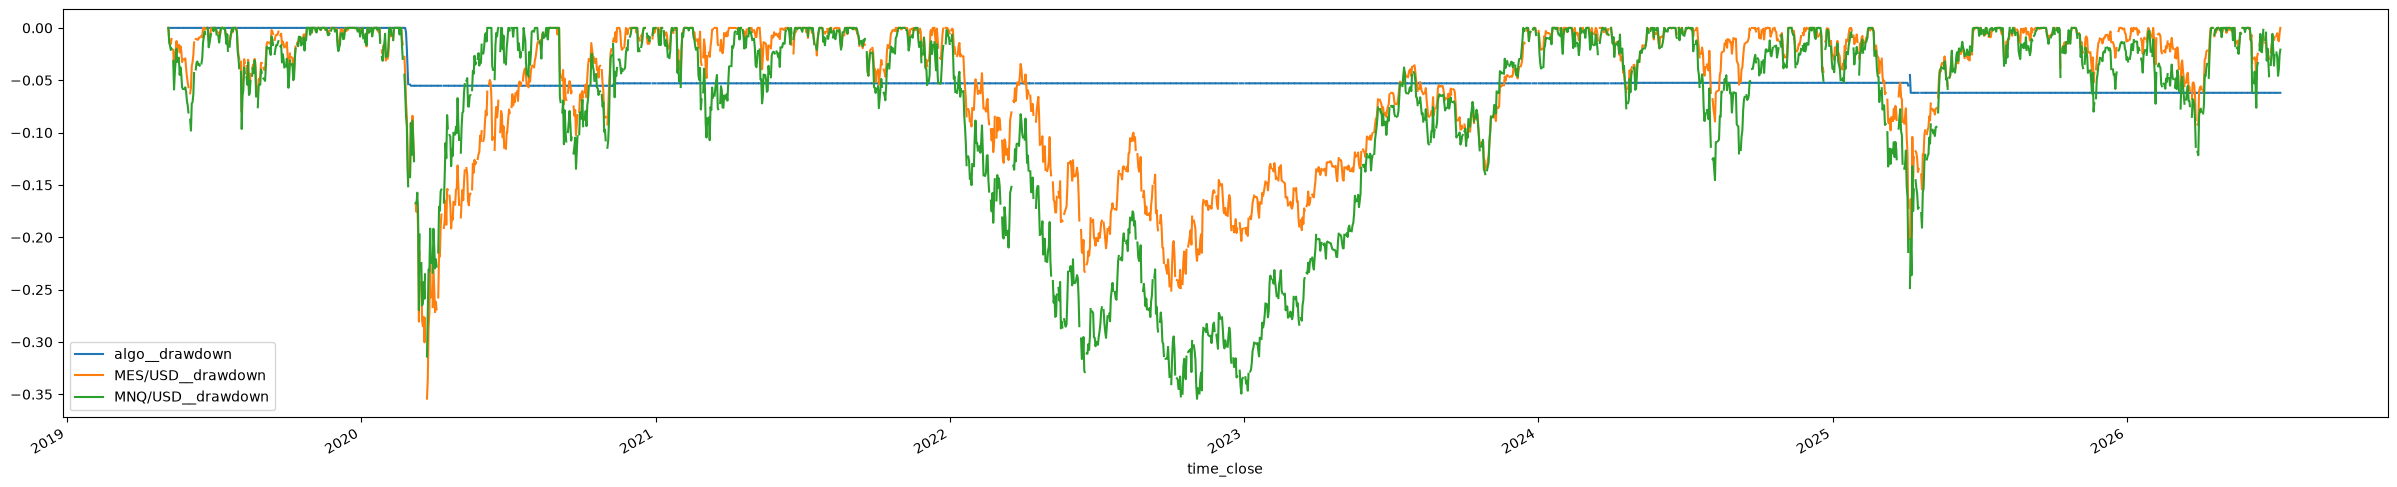

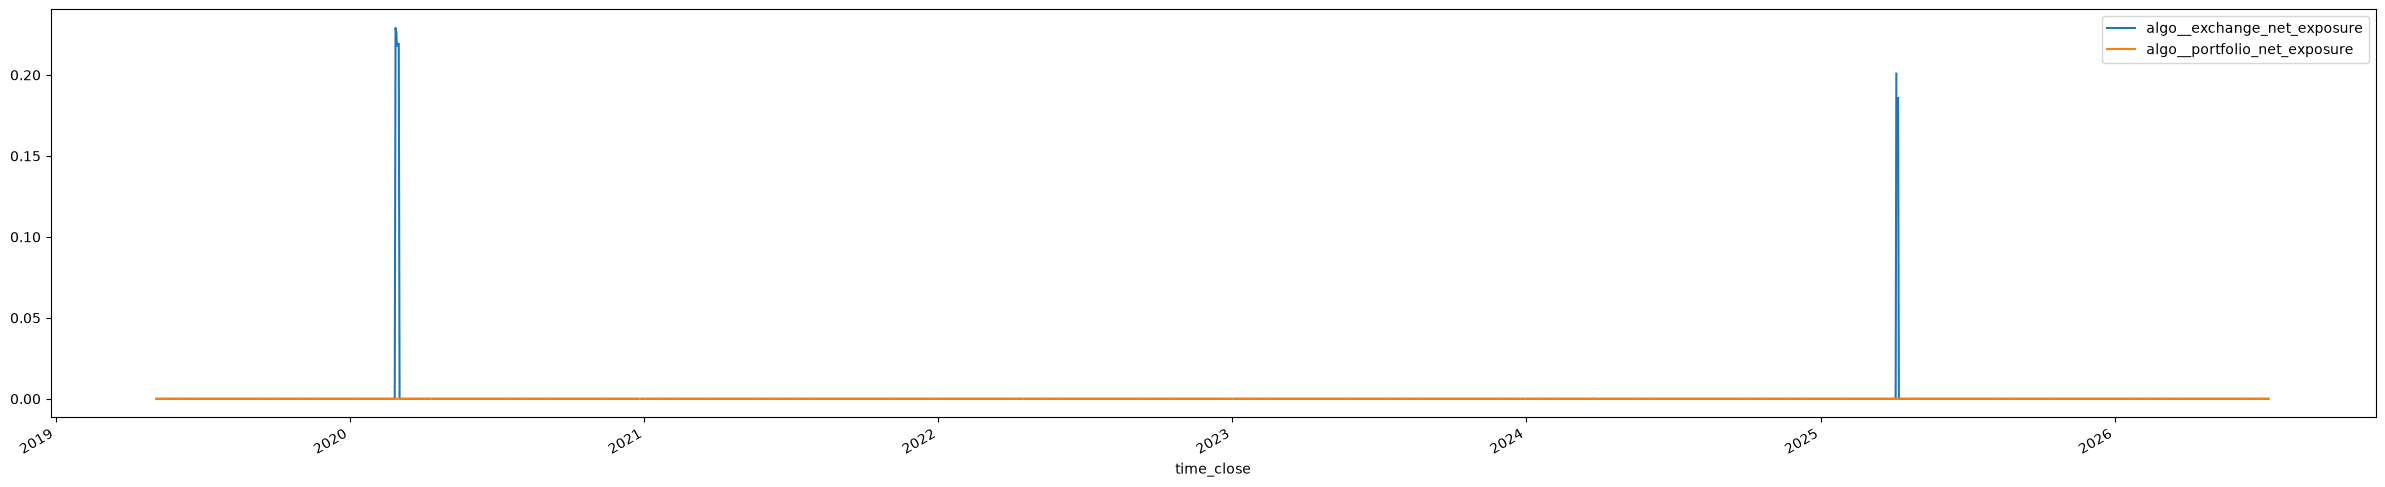

In [12]:
best_entry_z, best_exit_z = grid_results.iloc[0][["entry_z", "exit_z"]]
print(f"Best combo: entry_z={best_entry_z}, exit_z={best_exit_z}")
best_backtest, best_drawdown_mw = grid_backtests[(best_entry_z, best_exit_z)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", best_drawdown_mw.locked)

PERFORMANCE_SPLIT = "Y"
display(HTML(best_backtest.reporter.summary_html_table(split=PERFORMANCE_SPLIT)))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL_A}__cumulative_returns",
        f"{SYMBOL_B}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL_A}__drawdown",
        f"{SYMBOL_B}__drawdown",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure",
    ], figsize=(30, 6))


## Findings

**Net-negative across every grid combination -- a real gross edge exists, but a
2-leg pairs trade's transaction-cost structure destroys it.** All numbers below
are from the real event-driven engine (real Tradovate/Tradeify cost model), 2019-
05-05 -> 2026-07-12, 504,121 aligned 5-minute bars.

| entry_z | exit_z | net_return | sharpe | max_drawdown | closed_trades (legs) | win_rate |
|---|---|---|---|---|---|---|
| 1.5 | 0.5 | **-34.6%** | -0.577 | -45.3% | 3,844 | 48.8% |
| 1.5 | 0.0 | -37.6% | -0.607 | -44.9% | 3,476 | 48.8% |
| 2.0 | 0.0 | -38.3% | -0.729 | -41.8% | 3,094 | 47.8% |
| 2.5 | 0.0 | -38.1% | -0.811 | -41.5% | 2,806 | 47.4% |
| 2.0 | 0.5 | -39.6% | -0.835 | -43.7% | 3,234 | 48.1% |
| 2.5 | 0.5 | -39.1% | -0.957 | -40.3% | 2,852 | 47.6% |

**Every single combination is Sharpe-negative.** Tighter entries (entry_z=1.5)
are the least bad, not because they're good, but because wider entries
(entry_z=2.5) trade less often yet still lose more per trade -- consistent with
what's below, not tuning noise.

**CORRECTION (added after the fact -- an earlier version of this section
misread a metric)**: this section originally claimed a "+65.4% gross edge
destroyed by costs," citing `gross_return_percent`. That metric is **the final
wealth multiple x100, not a pre-fee return** (see `PerformanceAnalyzer`:
`gross_return_percent = gross_return * 100` vs `net_return_percent =
(gross_return - 1) * 100` -- the two always differ by exactly 100 points by
definition, so their gap says nothing about costs). The honest frictionless
read comes from the trade-level metrics instead: for the best combo,
**profit_factor = 1.0069** (frictionless, essentially exactly 1.0) and
**r_multiple_expectancy = 0.0000** -- i.e. **there was no meaningful pre-cost
edge in this signal at all**, and fees (dollar_profit_factor 0.892, with each
round trip paying commission+slippage on four fills -- open leg A, open leg B,
close leg A, close leg B) pushed a zero-edge signal firmly negative. (The
fee-total column read $0 in this run due to a separate bug -- `get_logs()`
returns rebalancer logs, not fills; fixed to `event_log.get_events()` in the
cell above but not re-run, since the conclusion doesn't depend on it.)

**This isn't a fast-scalping problem either** -- `avg_holding_period_min` for
the best combo is ~906 minutes (~15 hours), a perfectly reasonable holding
period. At ~1,922 round trips over 7.2 years (~267/year, ~1.1/trading day),
holding periods being "reasonable" doesn't save it: the four-fills structure
means costs scale with round-trip *count*, and ~1/day is still enough of them.

**Per-year Sharpe for the best combo is mixed but mostly negative**: 2019
+0.01, 2020 -1.62, 2021 -1.79, 2022 -1.28, 2023 -0.14, 2024 -0.62, **2025 +0.44,
2026 (partial) +0.76**. The only two genuinely positive years are the two most
recent -- an interesting echo of `cointegration/mes_mnq_m2k_cointegration.ipynb`'s
last-1-month Johansen result (which *did* find significant evidence of a
current joint cointegrating relationship among all three symbols, just not
specifically driven by the MES/MNQ pair in the pairwise Engle-Granger check).
Worth noting, not over-claiming: two decent years out of eight is exactly the
kind of pattern that same notebook's per-year stability check warned against
trusting.

**Account survived** (no drawdown-middleware breach) under the loosened 50%/50%
Tradeify limits, but that bar is loose by design (single-sleeve test) --
max_drawdown of -45% would blow through the *real* 4% Tradeify limit many times
over and isn't a result to build on.

**Bottom line (corrected)**: consistent with the up-front caveat about MES/MNQ
having the weakest cointegration evidence of the three pairs tested, this
notebook did not find a profitable pairs mean-reversion strategy on MES/MNQ --
and per the correction above, the rolling z-score signal showed **no
demonstrated frictionless edge** on this pair (profit_factor ~1.00) even before
the pairs-trade cost structure made it worse. A next step worth trying, not attempted here: coarser bars
(reducing round-trip frequency further) or a longer minimum-holding-period
lockout aimed specifically at cutting round-trip count, the same lever that
worked (or didn't) elsewhere in this repo's research -- or trading this same
mechanism on `M2K/MNQ` or `M2K/MES` instead, the pairs the cointegration
notebook actually found evidence for.
